In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report

In [2]:
train_path = r"F:\work\python\archive\classification_task\train"
test_path  = r"F:\work\python\archive\classification_task\test"

In [3]:
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_gen = test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 4002 images belonging to 4 classes.
Found 998 images belonging to 4 classes.
Found 1000 images belonging to 4 classes.


In [4]:
def channel_attention(x, ratio=8):
    channels = x.shape[-1]

    avg_pool = GlobalAveragePooling2D()(x)
    avg_pool = Dense(channels//ratio, activation='relu')(avg_pool)
    avg_pool = Dense(channels, activation='sigmoid')(avg_pool)
    avg_pool = Reshape((1,1,channels))(avg_pool)

    return Multiply()([x, avg_pool])

In [5]:
def build_vgg_channel():
    base = VGG16(weights='imagenet',
                 include_top=False,
                 input_shape=(224,224,3))

    for layer in base.layers[:-4]:
        layer.trainable = False

    x = base.output
    x = channel_attention(x)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    out = Dense(4, activation='softmax')(x)

    return Model(base.input, out)

In [8]:
def train_and_evaluate(model, name):

    model.compile(
        optimizer=Adam(learning_rate=3e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    early = EarlyStopping(monitor='val_loss',
                          patience=5,
                          restore_best_weights=True)

    model.fit(train_gen,
              validation_data=val_gen,
              epochs=5,
              callbacks=[early])

    loss, acc = model.evaluate(test_gen)
    print(f"\n{name} Test Accuracy: {acc*100:.2f}%")

    test_gen.reset()
    preds = model.predict(test_gen)
    y_pred = np.argmax(preds, axis=1)
    y_true = test_gen.classes

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred))

In [9]:
vgg_channel = build_vgg_channel()
train_and_evaluate(vgg_channel, "VGG16 Channel")

Epoch 1/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 330s 3s/step - accuracy: 0.6544 - loss: 0.8238 - val_accuracy: 0.7234 - val_loss: 0.8186
Epoch 2/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 739s 6s/step - accuracy: 0.8601 - loss: 0.4051 - val_accuracy: 0.8056 - val_loss: 0.6140
Epoch 3/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 771s 6s/step - accuracy: 0.8938 - loss: 0.3143 - val_accuracy: 0.8417 - val_loss: 0.4950
Epoch 4/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 330s 3s/step - accuracy: 0.8988 - loss: 0.2679 - val_accuracy: 0.8397 - val_loss: 0.5338
Epoch 5/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 703s 6s/step - accuracy: 0.9230 - loss: 0.2180 - val_accuracy: 0.8517 - val_loss: 0.4639
32/32 ━━━━━━━━━━━━━━━━━━━━ 242s 8s/step - accuracy: 0.8570 - loss: 0.4069

VGG16 Channel Test Accuracy: 85.70%
32/32 ━━━━━━━━━━━━━━━━━━━━ 237s 7s/step

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.79      0.86       254
           1       0.79      0.76      0.77       306
           2       0.

In [10]:
def spatial_attention(x):
    avg_pool = Lambda(lambda x: tf.reduce_mean(x, axis=3, keepdims=True))(x)
    max_pool = Lambda(lambda x: tf.reduce_max(x, axis=3, keepdims=True))(x)

    concat = Concatenate(axis=3)([avg_pool, max_pool])
    spatial = Conv2D(1, 7, padding='same', activation='sigmoid')(concat)

    return Multiply()([x, spatial])

In [11]:
def build_vgg_spatial():
    base = VGG16(weights='imagenet',
                 include_top=False,
                 input_shape=(224,224,3))

    for layer in base.layers[:-4]:
        layer.trainable = False

    x = base.output
    x = spatial_attention(x)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    out = Dense(4, activation='softmax')(x)

    return Model(base.input, out)

In [12]:
vgg_spatial = build_vgg_spatial()
train_and_evaluate(vgg_spatial, "VGG16 Spatial")


Epoch 1/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 366s 3s/step - accuracy: 0.6502 - loss: 0.8417 - val_accuracy: 0.7846 - val_loss: 0.6828
Epoch 2/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 409s 3s/step - accuracy: 0.8523 - loss: 0.4165 - val_accuracy: 0.7996 - val_loss: 0.6271
Epoch 3/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 390s 3s/step - accuracy: 0.8913 - loss: 0.3012 - val_accuracy: 0.8156 - val_loss: 0.5314
Epoch 4/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 476s 4s/step - accuracy: 0.9078 - loss: 0.2656 - val_accuracy: 0.8457 - val_loss: 0.5184
Epoch 5/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 513s 4s/step - accuracy: 0.9250 - loss: 0.2145 - val_accuracy: 0.8407 - val_loss: 0.5396
32/32 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.8550 - loss: 0.4464

VGG16 Spatial Test Accuracy: 85.50%
32/32 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.80      0.86       254
           1       0.80      0.73      0.77       306
           2       0.7

In [13]:
class SelfAttention(Layer):
    def __init__(self):
        super(SelfAttention, self).__init__()

    def build(self, input_shape):
        self.channels = input_shape[-1]
        self.query = Conv2D(self.channels//8, 1)
        self.key   = Conv2D(self.channels//8, 1)
        self.value = Conv2D(self.channels, 1)
        self.gamma = self.add_weight(shape=(1,),
                                     initializer="zeros",
                                     trainable=True)

    def call(self, x):
        batch_size = tf.shape(x)[0]
        h = x.shape[1]
        w = x.shape[2]
        c = self.channels

        query = self.query(x)
        key   = self.key(x)
        value = self.value(x)

        query = tf.reshape(query, [batch_size, -1, c//8])
        key   = tf.reshape(key, [batch_size, -1, c//8])
        value = tf.reshape(value, [batch_size, -1, c])

        attention = tf.matmul(query, key, transpose_b=True)
        attention = tf.nn.softmax(attention, axis=-1)

        out = tf.matmul(attention, value)
        out = tf.reshape(out, [batch_size, h, w, c])

        return self.gamma * out + x

In [14]:
def build_vgg_self():
    base = VGG16(weights='imagenet',
                 include_top=False,
                 input_shape=(224,224,3))

    for layer in base.layers[:-4]:
        layer.trainable = False

    x = base.output
    x = SelfAttention()(x)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    out = Dense(4, activation='softmax')(x)

    return Model(base.input, out)

In [15]:
vgg_self = build_vgg_self()
train_and_evaluate(vgg_self, "VGG16 Self") 

Epoch 1/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 304s 2s/step - accuracy: 0.6719 - loss: 0.8040 - val_accuracy: 0.7796 - val_loss: 0.6402
Epoch 2/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 314s 2s/step - accuracy: 0.8716 - loss: 0.3789 - val_accuracy: 0.8186 - val_loss: 0.5939
Epoch 3/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 313s 2s/step - accuracy: 0.8871 - loss: 0.3278 - val_accuracy: 0.8467 - val_loss: 0.4692
Epoch 4/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 316s 3s/step - accuracy: 0.9115 - loss: 0.2541 - val_accuracy: 0.8377 - val_loss: 0.6082
Epoch 5/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 315s 3s/step - accuracy: 0.9223 - loss: 0.2118 - val_accuracy: 0.8627 - val_loss: 0.5066
32/32 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.8200 - loss: 0.5016

VGG16 Self Test Accuracy: 82.00%
32/32 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.71      0.82       254
           1       0.73      0.70      0.72       306
           2       0.80   

In [17]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def print_confusion_matrix(model, test_gen, model_name):

    # Get predictions
    test_gen.reset()
    preds = model.predict(test_gen, verbose=0)
    y_pred = np.argmax(preds, axis=1)
    y_true = test_gen.classes

    # Compute CM
    cm = confusion_matrix(y_true, y_pred)
    class_labels = list(test_gen.class_indices.keys())

    # Plot
    plt.figure(figsize=(6,6))
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues',
                xticklabels=class_labels,
                yticklabels=class_labels)

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.tight_layout()
    plt.show()

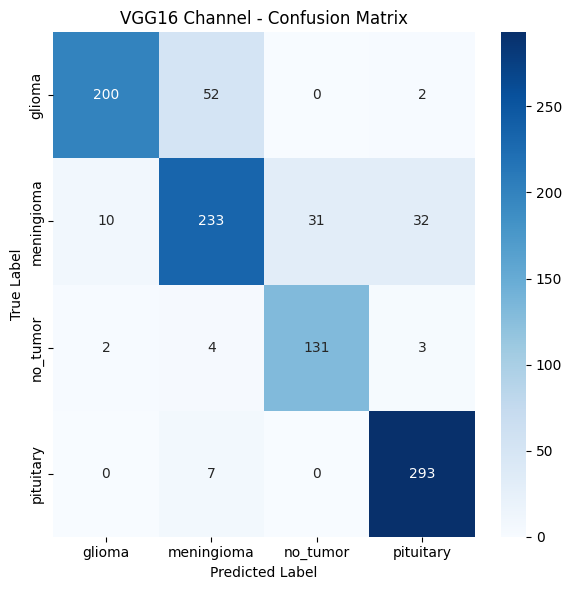

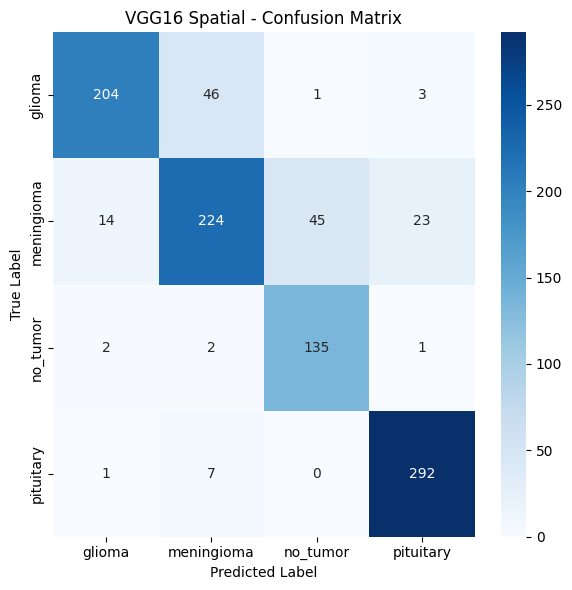

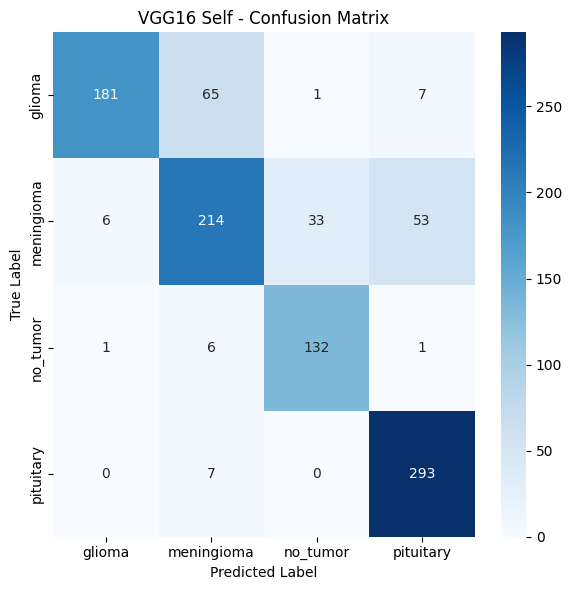

In [18]:
print_confusion_matrix(vgg_channel, test_gen, "VGG16 Channel")
print_confusion_matrix(vgg_spatial, test_gen, "VGG16 Spatial")
print_confusion_matrix(vgg_self, test_gen, "VGG16 Self")